# Section 1: Setup
## Step 1: Install and import required data libraries


In [74]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans,DBSCAN
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA


## Step 2: Upload the custom country metrics CSV dataset
Now we will load our country data. We use pandas to read the csv file. Then we show the first few rows to see what our data looks like.

In [75]:
df=pd.read_csv('Country-data.csv')
df.head()

,country,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
0,Afghanistan,90.2,10.0,7.58,44.9,1610,9.44,56.2,5.82,553
1,Albania,16.6,28.0,6.55,48.6,9930,4.49,76.3,1.65,4090
2,Algeria,27.3,38.4,4.17,31.4,12900,16.10,76.5,2.89,4460
3,Angola,119.0,62.3,2.85,42.9,5900,22.40,60.1,6.16,3530
4,Antigua and Barbuda,10.3,45.5,6.03,58.9,19100,1.44,76.8,2.13,12200


## Step 3: Execute the data cleaning chain
Cleaning data is super important before we put it into a computer learning model. In this step, we do many cleaning things. First, we remove any extra spaces from the column names, so we dont make errors later. Second, we take out any rows that are exactly same. Third, we make sure all numbers are actually numbers, except the country name. Last, if any numbers are missing, we fill them with the middle number (median) from that column. Median is better than average because it is not affected by very big or very small numbers.

In [76]:
#strip whitespace from column titles, so no extra spaces in names
df.columns=df.columns.str.strip()

# Check for duplicates before dropping, to see how many same rows we have
initial_rows=df.shape[0]
duplicates_count=df.duplicated().sum()
print(f"Start rows: {initial_rows}")
print(f"Duplicate rows found: {duplicates_count}")

#drop duplicate records, remove the same rows
df=df.drop_duplicates()
print(f"Rows after taking out duplicates: {df.shape[0]}")

#force numeric types for all continuous features, make sure they are numbers
numeric_cols=df.columns.drop('country')
df[numeric_cols]=df[numeric_cols].apply(pd.to_numeric,errors='coerce')

# Check for missing values before imputation, see what numbers are missing
missing_values_before=df[numeric_cols].isnull().sum()
print("\nMissing values before fixing:")
print(missing_values_before[missing_values_before > 0])

#impute missing values using median features, fill missing with middle number
df[numeric_cols]=df[numeric_cols].fillna(df[numeric_cols].median())

# Check for missing values after imputation, see if any are still missing
missing_values_after=df[numeric_cols].isnull().sum()
print("\nMissing values after fixing:")
print(missing_values_after[missing_values_after > 0])

print("\nData head after all cleaning steps:")
display(df.head())

Start rows: 167
Duplicate rows found: 0
Rows after taking out duplicates: 167

Missing values before fixing:
Series([], dtype: int64)

Missing values after fixing:
Series([], dtype: int64)

Data head after all cleaning steps:


,country,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
0,Afghanistan,90.2,10.0,7.58,44.9,1610,9.44,56.2,5.82,553
1,Albania,16.6,28.0,6.55,48.6,9930,4.49,76.3,1.65,4090
2,Algeria,27.3,38.4,4.17,31.4,12900,16.10,76.5,2.89,4460
3,Angola,119.0,62.3,2.85,42.9,5900,22.40,60.1,6.16,3530
4,Antigua and Barbuda,10.3,45.5,6.03,58.9,19100,1.44,76.8,2.13,12200


## Step 4. Exploratory Data Analysis (EDA)
we make correlation heatmap and boxplot to understand our data better and see outliers.

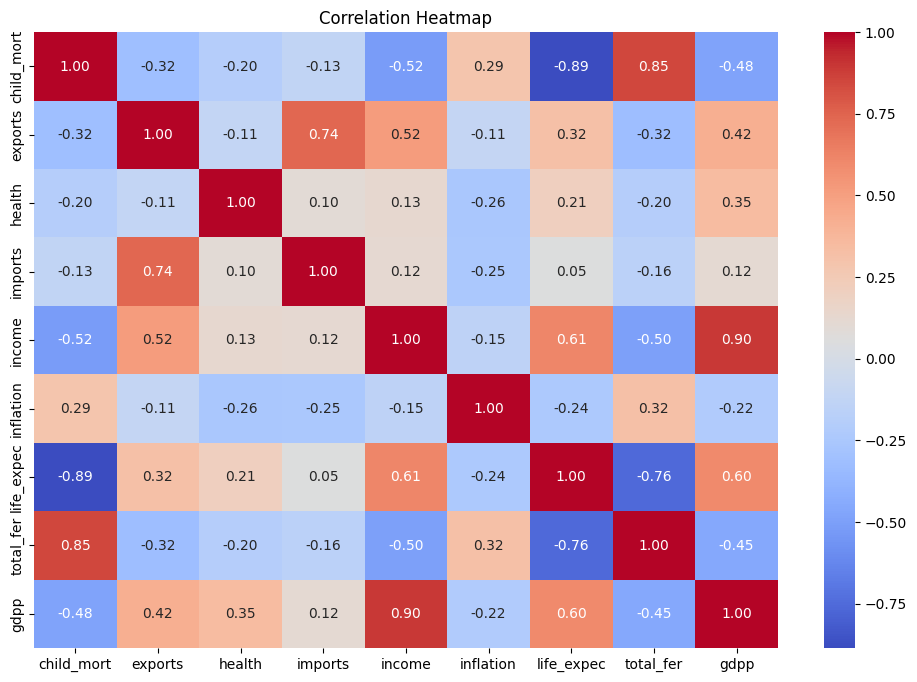

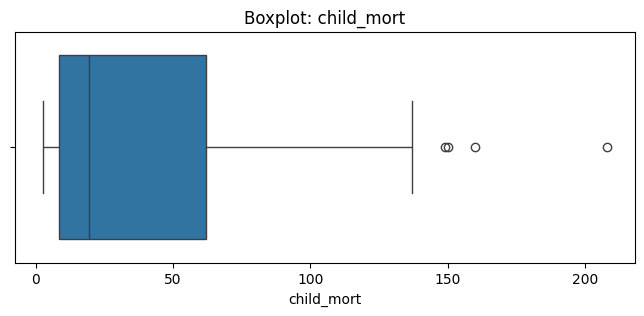

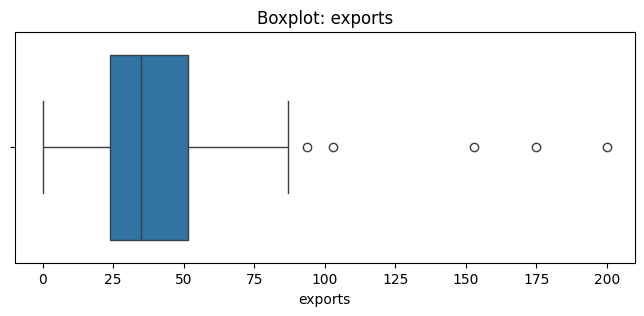

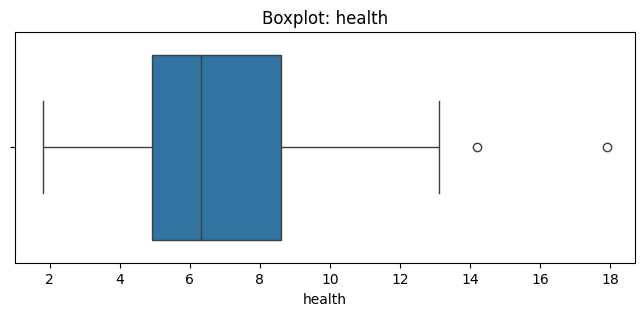

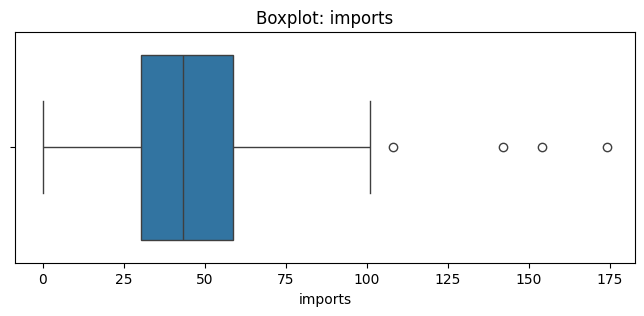

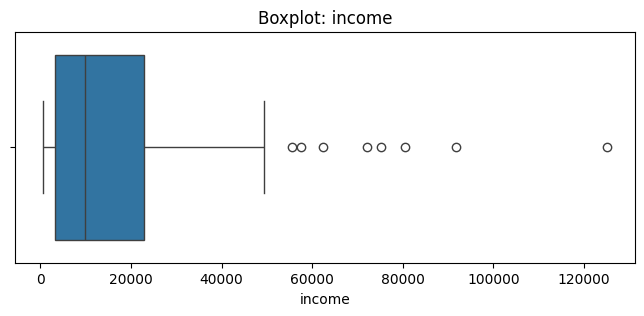

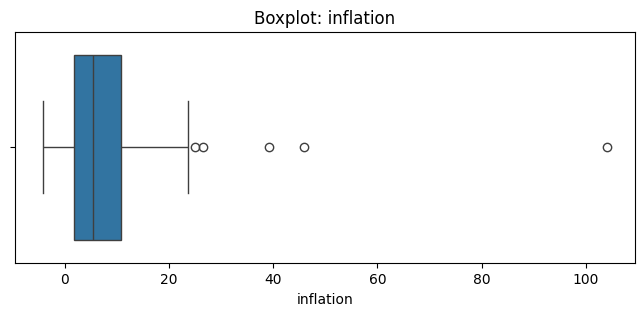

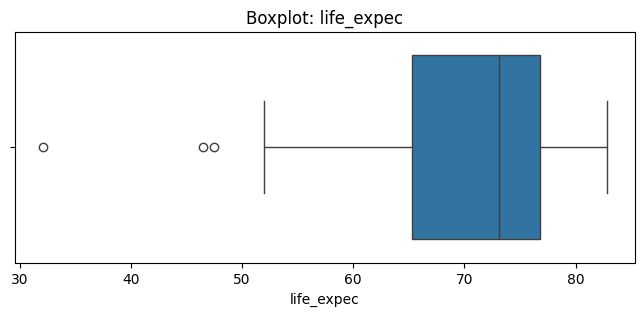

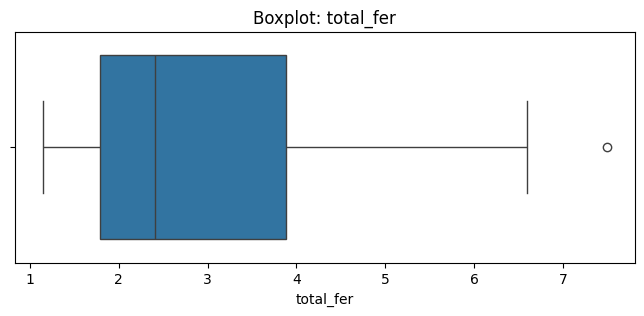

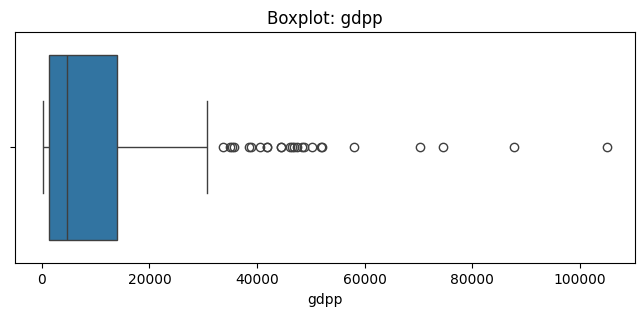

In [77]:
#correlation heatmap
plt.figure(figsize=(12,8))
sns.heatmap(df[numeric_cols].corr(),annot=True,cmap='coolwarm',fmt='.2f')
plt.title('Correlation Heatmap')
plt.show()

#boxplot for numeric column
for col in numeric_cols:
    plt.figure(figsize=(8,3))
    sns.boxplot(x=df[col])
    plt.title(f'Boxplot: {col}')
    plt.show()

## Step 5: Isolate continuous features and scale all rows
Computer learning models look at how far apart data points are. If we dont make numbers same size, then big numbers like a country's money (GDP) will make small numbers like how prices change (inflation) look not important. Here, we take out the country names because they are words and can't be used for math. Then we use StandardScaler to make all numbers have an average of 0 and how much they spread out be 1. This helps everything be fair.

In [78]:
country_names=df['country']
df_clust=df.drop('country',axis=1)

# Scale the data, make all numbers same 'size'
scaler=StandardScaler()
df_scaled_array=scaler.fit_transform(df_clust)
df_scaled=pd.DataFrame(df_scaled_array,columns=df_clust.columns)
display(df_scaled.head())

,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
0,1.291532,-1.138280,0.279088,-0.082455,-0.808245,0.157336,-1.619092,1.902882,-0.679180
1,-0.538949,-0.479658,-0.097016,0.070837,-0.375369,-0.312347,0.647866,-0.859973,-0.485623
2,-0.272833,-0.099122,-0.966073,-0.641762,-0.220844,0.789274,0.670423,-0.038404,-0.465376
3,2.007808,0.775381,-1.448071,-0.165315,-0.585043,1.387054,-1.179234,2.128151,-0.516268
4,-0.695634,0.160668,-0.286894,0.497568,0.101732,-0.601749,0.704258,-0.541946,-0.041817


## Step 5: Optimization loop testing for Elbow Method
To find the best number of groups for our K-Means model, we use the Elbow Method. We try many different 'k' values, from 2 to 10. For each 'k', we make a temporary model and save its 'inertia' value. Inertia tells us how tight the groups are. Then we draw a picture called an Elbow Method line plot. We look for where the line bends, like an elbow, to find our best 'k'.

    k      inertia
0   2  1063.482560
1   3   831.535158
2   4   751.191575
3   5   620.362153
4   6   563.560286
5   7   496.269600
6   8   490.800836
7   9   455.017022
8  10   433.538441


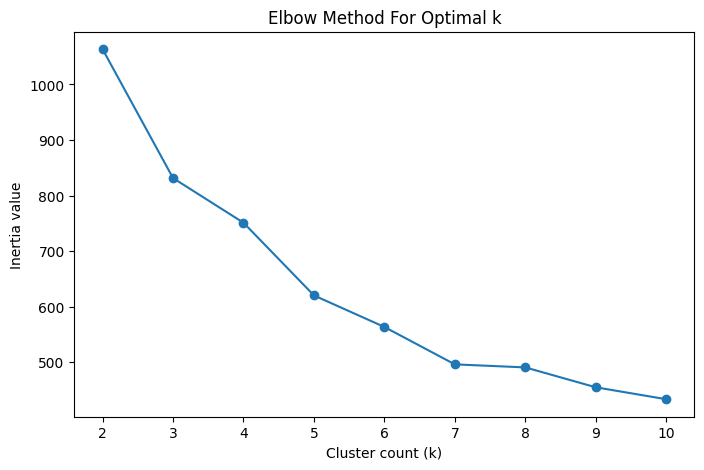

In [79]:
inertia=[]
K=range(2,11)
for k in K:
    km=KMeans(n_clusters=k,random_state=42)
    km.fit(df_scaled_array)
    inertia.append(km.inertia_)

elbows=pd.DataFrame({
    "k":list(K),
    "inertia":inertia
})
print(elbows)

#chart the curve in Elbow Method line plot, draw the elbow picture
plt.figure(figsize=(8,5))
plt.plot(K,inertia,marker='o')
plt.xlabel('Cluster count (k)')
plt.ylabel('Inertia value')
plt.title('Elbow Method For Optimal k')
plt.show()

## Step 6: Define baseline cluster count and train K-Means model
If we look at the elbow plot, we can see the line bends at k=3. So, we choose 3 as our best number of groups. We make our final K-Means model using k=3 and find out which group each country belongs to. We put these group labels back into our main data table.

In [80]:
best_k=3
kmeans=KMeans(n_clusters=best_k,random_state=42)
kmeans_labels=kmeans.fit_predict(df_scaled_array)
df['kmeans_cluster']=kmeans_labels
df.head()

,country,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp,kmeans_cluster
0,Afghanistan,90.2,10.0,7.58,44.9,1610,9.44,56.2,5.82,553,2
1,Albania,16.6,28.0,6.55,48.6,9930,4.49,76.3,1.65,4090,0
2,Algeria,27.3,38.4,4.17,31.4,12900,16.10,76.5,2.89,4460,0
3,Angola,119.0,62.3,2.85,42.9,5900,22.40,60.1,6.16,3530,2
4,Antigua and Barbuda,10.3,45.5,6.03,58.9,19100,1.44,76.8,2.13,12200,0


## Step 7: Evaluate clustering performance
We check how good our groups are by calculating something called the silhouette_score. This score goes from -1 to 1. If the score is higher, it means our groups are very separate, and countries inside one group are very much alike. This is a good thing for our grouping model.

In [81]:
score=silhouette_score(df_scaled_array,kmeans_labels)
print("Silhouette Score:",score)

Silhouette Score: 0.285600988953231


## Step 8: Build secondary comparative clustering model using DBSCAN
Now we make another grouping model called DBSCAN. We want to see if it makes similar groups. DBSCAN works by looking at how close data points are, not by finding a center. We set 'eps' (how far apart points can be to be in same group) to 1.5 and 'min_samples' (how many points needed to form a group) to 5, like we were told.

In [82]:
dbscan=DBSCAN(eps=1.5,min_samples=5) # make DBSCAN model with given settings
dbscan_labels=dbscan.fit_predict(df_scaled)
df['DBSCAN_Cluster']=dbscan_labels
display(df.head())

,country,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp,kmeans_cluster,DBSCAN_Cluster
0,Afghanistan,90.2,10.0,7.58,44.9,1610,9.44,56.2,5.82,553,2,0
1,Albania,16.6,28.0,6.55,48.6,9930,4.49,76.3,1.65,4090,0,0
2,Algeria,27.3,38.4,4.17,31.4,12900,16.10,76.5,2.89,4460,0,0
3,Angola,119.0,62.3,2.85,42.9,5900,22.40,60.1,6.16,3530,2,-1
4,Antigua and Barbuda,10.3,45.5,6.03,58.9,19100,1.44,76.8,2.13,12200,0,0


## Step 9: Project high-dimensional records and map to color-coded scatterplot
Our data has many different features, so it's hard to draw on a flat paper. We use something called PCA (Principal Component Analysis) to make the data smaller, only 2 main parts. Then we can draw a nice 2D scatterplot. We use different colors for our K-Means groups, so we can see how well our country groups are separated on the picture.

Explained variance ratio: [0.4595174  0.17181626]


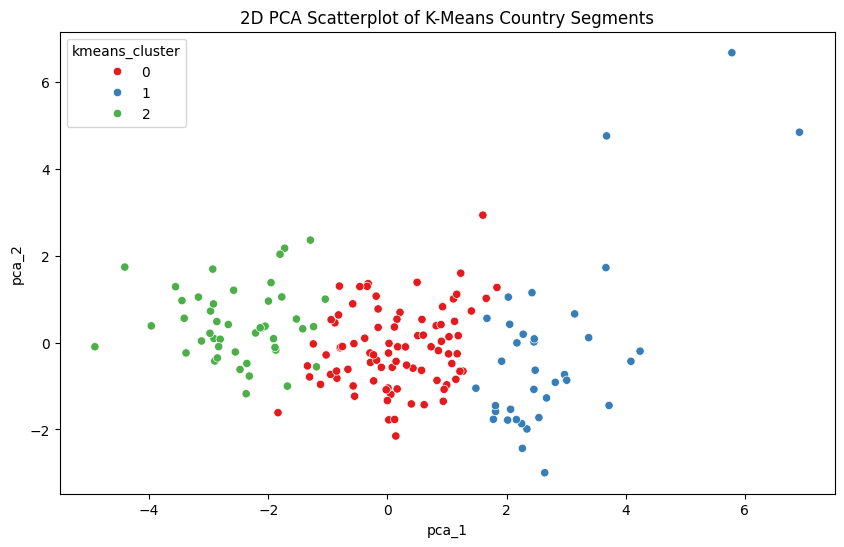

In [83]:
pca=PCA(n_components=2) # make PCA to make data 2D
pca_data=pca.fit_transform(df_scaled_array)
print("Explained variance ratio:", pca.explained_variance_ratio_)
df['pca_1']=pca_data[:,0]
df['pca_2']=pca_data[:,1]

plt.figure(figsize=(10,6))
sns.scatterplot(x='pca_1',y='pca_2',hue='kmeans_cluster',data=df,palette='Set1')
plt.title('2D PCA Scatterplot of K-Means Country Segments')
plt.show()

## 11. Cluster Profiling and Sample Countries
we check mean value of all feature for each cluster to understand them. we also print some sample country name for each group.

In [84]:
#check mean profile
profile=df.groupby('kmeans_cluster')[numeric_cols].mean().round(2)
display(profile)

#print sample countries
for cluster_id in sorted(df['kmeans_cluster'].unique()):
    sample_countries=df[df['kmeans_cluster']==cluster_id]['country'].head(10).tolist()
    print("Cluster",cluster_id,"sample countries:",sample_countries)

,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
kmeans_cluster,,,,,,,,,
0,22.46,40.27,6.25,47.36,12321.74,7.72,72.57,2.34,6461.77
1,5.00,58.74,8.81,51.49,45672.22,2.67,80.13,1.75,42494.44
2,95.11,28.60,6.30,42.31,3539.84,11.99,59.06,5.07,1766.71


Cluster 0 sample countries: ['Albania', 'Algeria', 'Antigua and Barbuda', 'Argentina', 'Armenia', 'Azerbaijan', 'Bahamas', 'Bangladesh', 'Barbados', 'Belarus']
Cluster 1 sample countries: ['Australia', 'Austria', 'Bahrain', 'Belgium', 'Brunei', 'Canada', 'Cyprus', 'Czech Republic', 'Denmark', 'Finland']
Cluster 2 sample countries: ['Afghanistan', 'Angola', 'Benin', 'Burkina Faso', 'Burundi', 'Cameroon', 'Central African Republic', 'Chad', 'Comoros', 'Congo, Dem. Rep.']


## Section 14: Observations

Here are some thing we see from our group and data:

1. **Low-development area**: Country in Group 2 (KMeans red color in plot) have many baby dying young and very low income. People live short life here. These are very poor country and they need help.
2. **Top economic zone**: Country in Group 0 (blue color in plot) have very less child dying and lots of money for each person. People live long life. These are rich country and very developed.
3. **Middle developing country**: Group 1 (green color in plot) is in the middle. They are better than Group 2 but not as good as Group 0. These country are still growing and getting better.
4. **Child mortality is big sign**: If many child die, it show how much developed a country is. More child death mean less developed, because they have bad health and not enough food.
5. **Income and life expectancy**: We see when country have more money, people also live longer. This make sense because rich country can pay for better hospital and good food for everyone.